# **Цель:** оценить эффект фичи, раскатанной на 100k пользователей без A/B-теста, через подбор «близнецов» (matching) из непролеченной популяции и сравнение целевой метрики.

 **Ключевые допущения:**
 - Отбор в фичу зависит только от **наблюдаемых** предпериодных признаков (unconfoundedness / CIA). В синтетике это смоделировано явно (selection on observables).
 - Матчинг строится **только по предпериоду**; постпериодная метрика в признаки матчинга не входит.

 **Этапы:**
 1. Генерация синтетики с **зашитым истинным эффектом** и неслучайным отбором в фичу (чтобы можно было провалидировать сам метод)
 2. Предобработка: пропуски, **frequency-кодирование** категорий (единый фит на кандидатах), масштабирование — всё во float32
 3. PCA до ~10 компонент
 4. FAISS `IndexIVFPQ` (память) + **переранжирование топ-k точным косинусом**
 5. Жадное разрешение коллизий (уникальные пары) + **caliper**
 6. Поствалидация (уникальность, отсутствие treated среди кандидатов)
 7. **Диагностика баланса (SMD до/после матчинга)**
 8. **Оценка эффекта: наивная vs matching vs matching+DiD, с тестом значимости и 95% ДИ**


## 1. Импорт библиотек

In [ ]:
pip install faiss-cpu


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import faiss
import time
import warnings
warnings.filterwarnings('ignore')


## 2. Генерация синтетических данных

Создаём DataFrame с 15 признаками, имитирующими банковского клиента.


In [28]:
np.random.seed(42)

# В проде база ~20 млн — обрабатывать батчами (см. примечание о памяти ниже).
# Для запуска на 8 ГБ берём меньшую базу; вся логика идентична.
N_BASE = 2_000_000        # вся популяция
N_TEST = 100_000          # сколько пользователей реально получили фичу
TRUE_EFFECT = 0.30        # ИСТИННЫЙ эффект фичи (зашит, чтобы проверить, что метод его восстанавливает)

def generate_features(n_users):
    """Предпериодные признаки — то, что известно ДО раскатки фичи. Сразу во float32."""
    data = {
        'user_id': np.arange(n_users, dtype=np.int64),
        'recency_days': np.random.exponential(scale=30, size=n_users).astype(np.float32),
        'frequency': np.random.poisson(lam=5, size=n_users).astype(np.float32),
        'monetary_sum': np.random.exponential(scale=5000, size=n_users).astype(np.float32),
        'logins_last_30d': np.random.poisson(lam=15, size=n_users).astype(np.float32),
        'transactions_last_30d': np.random.poisson(lam=10, size=n_users).astype(np.float32),
        'has_credit_card': np.random.binomial(1, 0.4, size=n_users).astype(np.float32),
        'has_deposit': np.random.binomial(1, 0.3, size=n_users).astype(np.float32),
        'has_mortgage': np.random.binomial(1, 0.1, size=n_users).astype(np.float32),
        'region': np.random.choice(['Москва', 'СПб', 'Регион_А', 'Регион_Б', 'Регион_В'], size=n_users),
        'age': np.random.normal(loc=45, scale=15, size=n_users).astype(np.float32),
        'gender': np.random.choice(['M', 'F'], size=n_users),
        'os': np.random.choice(['iOS', 'Android', 'Windows', 'Other'], size=n_users),
        'night_share': np.random.beta(a=2, b=5, size=n_users).astype(np.float32),
        'avg_check': np.random.exponential(scale=1000, size=n_users).astype(np.float32),
        'tenure_months': np.random.exponential(scale=24, size=n_users).astype(np.float32),
    }
    df = pd.DataFrame(data)
    df.loc[df.sample(frac=0.05, random_state=1).index, 'avg_check'] = np.nan
    df.loc[df.sample(frac=0.03, random_state=2).index, 'tenure_months'] = np.nan
    return df

df_all = generate_features(N_BASE)

# --- Предпериодная целевая метрика (напр. число транзакций за пред-окно) ---
# Коррелирует с активностью — именно её и будем выравнивать матчингом.
df_all['target_pre'] = (
    0.5 * df_all['transactions_last_30d']
    + 0.3 * df_all['logins_last_30d']
    + 2.0 * df_all['has_credit_card']
    + np.random.normal(0, 1, size=N_BASE)
).astype(np.float32)

# --- НЕслучайный отбор в фичу (selection on observables) ---
# Фичу чаще давали активным клиентам => наивное сравнение БУДЕТ смещено.
logit = (-6.0
         + 0.08 * df_all['logins_last_30d']
         + 0.10 * df_all['transactions_last_30d']
         + 0.5  * df_all['has_credit_card'])
p = 1.0 / (1.0 + np.exp(-logit))
p = (p / p.sum()).values
treated_idx = np.random.choice(N_BASE, size=N_TEST, replace=False, p=p)
df_all['treated'] = 0
df_all.loc[treated_idx, 'treated'] = 1

# --- Постпериодная метрика с ЗАШИТЫМ эффектом ---
# target_post = базовая динамика (зависит от target_pre и активности) + эффект*treated + шум.
# Изменение (post - pre) = 0.2*logins + TRUE_EFFECT*treated + шум  -> удобно для DiD.
df_all['target_post'] = (
    df_all['target_pre']
    + 0.2 * df_all['logins_last_30d']
    + TRUE_EFFECT * df_all['treated']
    + np.random.normal(0, 1, size=N_BASE)
).astype(np.float32)

print(f"База: {N_BASE:,}, получили фичу (treated): {int(df_all['treated'].sum()):,}")
print(f"Зашитый истинный эффект: {TRUE_EFFECT}")


База: 2,000,000, получили фичу (treated): 100,000
Зашитый истинный эффект: 0.3


In [29]:
# Тестовые = получившие фичу; кандидаты = НЕ получавшие.
test_df = df_all[df_all['treated'] == 1].copy()
cand_df = df_all[df_all['treated'] == 0].copy()

test_user_ids = set(test_df['user_id'])
cand_user_ids = set(cand_df['user_id'])
assert test_user_ids.isdisjoint(cand_user_ids), "Пересечение тестовых и кандидатов!"

# Реальные id кандидатов в порядке следования (для маппинга позиций FAISS -> user_id)
cand_ids = cand_df['user_id'].values
print(f"Тестовых (treated): {len(test_df):,}, Кандидатов: {len(cand_df):,}")


Тестовых (treated): 100,000, Кандидатов: 1,900,000


## 3. Предобработка признаков



### 3.1 Обработка пропусков
 - Для бинарных и счётных признаков → 0
 - Для непрерывных (avg_check, tenure_months) → медиана


In [30]:
def fill_missing(df, medians):
    df = df.copy()
    for col, m in medians.items():
        df[col] = df[col].fillna(m)
    return df

# Медианы считаем по кандидатам и применяем к обоим наборам (без утечки из treated).
medians = {c: cand_df[c].median() for c in ['avg_check', 'tenure_months']}
test_df = fill_missing(test_df, medians)
cand_df = fill_missing(cand_df, medians)


### 3.2 Кодирование категориальных признаков

`LabelEncoder` для региона/ОС задаёт **ложный порядок** (Москва=1, СПб=2…), по которому потом считается расстояние — это неверно. Используем **frequency encoding** (доля категории), фит — **один раз на кандидатском пуле** и применяем к обоим наборам, чтобы шкала была единой и без утечки. Пол → 0/1.


In [31]:
def make_freq_maps(df, cols):
    """Доля каждой категории, посчитанная на кандидатах."""
    return {c: df[c].value_counts(normalize=True) for c in cols}

def encode_categorical(df, freq_maps):
    df = df.copy()
    df['gender_bin'] = df['gender'].map({'M': 0, 'F': 1}).astype(np.float32)
    for c in ['region', 'os']:
        df[c + '_freq'] = df[c].map(freq_maps[c]).fillna(0.0).astype(np.float32)
    df.drop(['region', 'gender', 'os'], axis=1, inplace=True)
    return df

freq_maps = make_freq_maps(cand_df, ['region', 'os'])   # фит на кандидатах 
test_df = encode_categorical(test_df, freq_maps)
cand_df = encode_categorical(cand_df, freq_maps)

assert test_df.isnull().sum().sum() == 0
assert cand_df.isnull().sum().sum() == 0


### 3.3 Масштабирование числовых признаков

 Используем `RobustScaler` – устойчив к выбросам.

 Выделим числовые столбцы (кроме user_id).


In [32]:
# Матчимся ТОЛЬКО по предпериоду. Исключаем id, флаг лечения и ПОСТ-метрику (post-treatment!).
# target_pre оставляем — это валидный предпериодный признак.
exclude = {'user_id', 'treated', 'target_post'}
match_features = [c for c in test_df.columns if c not in exclude]
print("Признаки матчинга:", match_features)

# RobustScaler устойчив к выбросам. Фит на кандидатах, результат сразу во float32.
scaler = RobustScaler()
cand_scaled = scaler.fit_transform(cand_df[match_features]).astype(np.float32)
test_scaled = scaler.transform(test_df[match_features]).astype(np.float32)


Признаки матчинга: ['recency_days', 'frequency', 'monetary_sum', 'logins_last_30d', 'transactions_last_30d', 'has_credit_card', 'has_deposit', 'has_mortgage', 'age', 'night_share', 'avg_check', 'tenure_months', 'target_pre', 'gender_bin', 'region_freq', 'os_freq']


### 3.4 PCA (снижение размерности до 10)

 Обучаем на кандидатах, применяем к обоим наборам.


In [33]:
pca = PCA(n_components=10, random_state=42)
cand_pca = pca.fit_transform(cand_scaled).astype(np.float32)
test_pca = pca.transform(test_scaled).astype(np.float32)

del cand_scaled, test_scaled   # освобождаем память

print(f"Размерность после PCA: {cand_pca.shape[1]}, "
      f"объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2f}")


Размерность после PCA: 10, объяснённая дисперсия: 0.86


## 4. Подготовка векторов для FAISS

 - Приводим к float32 (требование FAISS)
 - Нормализуем векторы для косинусного расстояния (внутреннее произведение)


In [34]:
cand_vec = cand_pca.astype(np.float32)
test_vec = test_pca.astype(np.float32)

# Нормализация L2 (чтобы использовать косинус)
faiss.normalize_L2(cand_vec)
faiss.normalize_L2(test_vec)

## 5. Построение FAISS-индекса (IndexIVFPQ)

 - `d=10`, `nlist` — число кластеров, `M=5` сегментов PQ (d делится на M), `nbits=8`.
 - **Обучаем на случайной подвыборке достаточного размера** (FAISS требует ~30–40·nlist точек; 10k для nlist=1024 — мало и даёт мусорные центроиды).

 **О памяти (узкое место — не FAISS, а препроцессинг):** сам индекс крошечный (≈ M байт/вектор). Реальный риск — float64-копии полной матрицы в `RobustScaler`/`PCA` и копии DataFrame. Поэтому всё ведём во **float32** и удаляем промежуточные массивы. На проде 20 млн признаки и индекс надо строить **батчами** (`index.add` по кускам), не материализуя всю матрицу разом.


In [35]:
# cand_vec / test_vec — нормализованные float32-векторы из предыдущей ячейки
d = cand_vec.shape[1]
nlist = 1024 if len(cand_vec) > 500_000 else 256
M = 5
assert d % M == 0, "d должно делиться на M"

quantizer = faiss.IndexFlatIP(d)               # Inner Product по нормированным = косинус
index = faiss.IndexIVFPQ(quantizer, d, nlist, M, 8)

# Обучение на случайной подвыборке достаточного размера (~40*nlist, но не меньше 200k)
rng = np.random.default_rng(42)
train_size = min(len(cand_vec), max(40 * nlist, 200_000))
train_idx = rng.choice(len(cand_vec), size=train_size, replace=False)
print(f"Обучение индекса на {train_size:,} векторах...")
start = time.time()
index.train(cand_vec[train_idx])
print(f"Обучение завершено за {time.time()-start:.2f} сек.")

print("Добавление векторов в индекс...")
start = time.time()
index.add(cand_vec)                            # на проде — батчами
print(f"Добавлено {index.ntotal:,} векторов за {time.time()-start:.2f} сек.")

index.nprobe = 32                              # больше -> точнее, но медленнее
del train_idx


Обучение индекса на 200,000 векторах...
Обучение завершено за 1.21 сек.
Добавление векторов в индекс...
Добавлено 1,900,000 векторов за 2.16 сек.


## 6. Поиск топ-50 соседей для каждого тестового


In [36]:

k = 50
print("Поиск ближайших соседей...")
start = time.time()
distances, indices = index.search(test_vec, k)
print(f"Поиск завершён за {time.time()-start:.2f} сек. для {len(test_vec)} запросов.")

# distances – косинусное расстояние (чем больше, тем ближе, т.к. Inner Product нормализованных векторов)
# indices – номера векторов в индексе (соответствуют порядку добавления)


Поиск ближайших соседей...
Поиск завершён за 3.82 сек. для 100000 запросов.


## 7. Переранжирование + жадное разрешение коллизий

 IVFPQ возвращает **приближённые** расстояния. Для матчинга нужна точность, поэтому топ-k кандидатов **переранжируем точным косинусом** по исходным нормированным векторам. Затем собираем пары `(test_idx, cand_idx, score)`, сортируем по убыванию точного score и жадно назначаем уникальные пары (каждый кандидат — максимум одному тестовому).


In [37]:
# Переранжирование: для каждого тестового пересчитываем ТОЧНЫЙ косинус к его k соседям
# (нормированные векторы -> inner product = косинус) и собираем пары.
pairs = []
for i in range(len(test_vec)):
    neigh = indices[i]
    ti = test_vec[i]
    for j in range(k):
        c = neigh[j]
        if c != -1:
            score = float(cand_vec[c] @ ti)   # точный косинус вместо PQ-приближения
            pairs.append((i, int(c), score))

print(f"Всего пар-кандидатов: {len(pairs):,}")

# Сортируем по убыванию точного score и жадно назначаем уникальные пары
pairs.sort(key=lambda x: x[2], reverse=True)
matched_test, matched_cand, final_pairs = set(), set(), []
for test_idx, cand_idx, score in pairs:
    if test_idx not in matched_test and cand_idx not in matched_cand:
        matched_test.add(test_idx)
        matched_cand.add(cand_idx)
        final_pairs.append((test_idx, cand_idx, score))
        if len(final_pairs) == len(test_vec):
            break

print(f"Назначено уникальных пар: {len(final_pairs):,} из {len(test_vec):,} тестовых")


Всего пар-кандидатов: 5,000,000
Назначено уникальных пар: 100,000 из 100,000 тестовых


In [38]:
result = pd.DataFrame(final_pairs, columns=['test_idx', 'cand_idx', 'score'])


In [39]:
result['real_cand_id'] = cand_ids[result['cand_idx'].values]
# Проверяем, что ни один real_cand_id не входит в test_user_ids
assert not any(result['real_cand_id'].isin(test_user_ids)), "Найден кандидат из тестовой группы!"

## 8. Поствалидация и фильтрация


In [40]:
result = pd.DataFrame(final_pairs, columns=['test_idx', 'cand_idx', 'score'])

# 1) Все ли тестовые получили пару
missing = set(range(len(test_vec))) - set(result['test_idx'])
print("OK: все тестовые получили пару." if not missing else f"Внимание: {len(missing)} без пары.")

# 2) Уникальность тестовых и близнецов 
assert result['test_idx'].nunique() == len(result)
assert result['cand_idx'].nunique() == len(result)

# 3) Близнецы действительно вне тестовой группы.
#    ВАЖНО: cand_idx — это позиция в cand_df, её НЕЛЬЗЯ сравнивать с n_test (была ошибка).
#    Правильно: маппим позицию -> реальный user_id и проверяем по множеству treated.
real_cand_id = cand_ids[result['cand_idx'].values]
assert not np.isin(real_cand_id, list(test_user_ids)).any(), "Кандидат из тестовой группы!"
print("OK: все близнецы вне тестовой группы.")

# 4) Caliper: отбрасываем пары с плохим качеством матча (низкий косинус).
#    Здесь — порог по 10-му перцентилю score как демонстрация. В проде лучше абсолютный
#    порог на стандартизованном расстоянии, откалиброванный по SMD (см. след. раздел):
#    тех, у кого нет хорошего близнеца, исключаем (и сообщаем, скольких потеряли).
CALIPER = result['score'].quantile(0.10)
matched = result[result['score'] >= CALIPER].copy().reset_index(drop=True)
print(f"Caliper score>={CALIPER:.4f}: оставлено {len(matched):,} из {len(result):,} "
      f"({100*len(matched)/len(result):.1f}%).")


OK: все тестовые получили пару.
OK: все близнецы вне тестовой группы.
Caliper score>=0.9678: оставлено 90,000 из 100,000 (90.0%).


In [41]:
# Реальные user_id для финальных (отфильтрованных) пар.
# test_idx — позиция в test_df, cand_idx — позиция в cand_df.
matched['test_user_id'] = test_df['user_id'].values[matched['test_idx'].values]
matched['cand_user_id'] = cand_ids[matched['cand_idx'].values]

matched[['test_user_id', 'cand_user_id', 'score']].to_csv('matched_pairs.csv', index=False)
print(f"Сохранено пар: {len(matched):,}")


Сохранено пар: 90,000


## Диагностика баланса (SMD до/после матчинга)

 Из-за неслучайного отбора активные признаки (logins, transactions, has_credit_card, target_pre) были разбалансированы между treated и всей популяцией. Хороший матчинг должен снизить |SMD| этих признаков до < 0.1 — это и проверяем.


In [42]:
# |SMD| по предпериодным признакам до и после матчинга. |SMD| < 0.1 — хороший баланс.
def smd(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2.0)
    return 0.0 if pooled == 0 else (a.mean() - b.mean()) / pooled

pre_cols = ['recency_days', 'frequency', 'monetary_sum', 'logins_last_30d',
            'transactions_last_30d', 'has_credit_card', 'has_deposit', 'has_mortgage',
            'age', 'night_share', 'avg_check', 'tenure_months', 'target_pre']

treated_all  = df_all[df_all['treated'] == 1]                              # все treated
pool_all     = df_all[df_all['treated'] == 0]                              # весь кандидатский пул (до)
treated_m    = df_all[df_all['user_id'].isin(matched['test_user_id'])]     # treated после caliper
control_m    = df_all[df_all['user_id'].isin(matched['cand_user_id'])]     # подобранные близнецы

rows = []
for c in pre_cols:
    rows.append({
        'feature': c,
        'SMD_before': abs(smd(treated_all[c].fillna(treated_all[c].median()),
                              pool_all[c].fillna(pool_all[c].median()))),
        'SMD_after':  abs(smd(treated_m[c].fillna(treated_m[c].median()),
                              control_m[c].fillna(control_m[c].median()))),
    })
balance = pd.DataFrame(rows).sort_values('SMD_before', ascending=False)
print(balance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print(f"\n|SMD|>0.1 — до матчинга: {(balance['SMD_before']>0.1).sum()}, "
      f"после: {(balance['SMD_after']>0.1).sum()}")

              feature  SMD_before  SMD_after
           target_pre       0.457      0.016
transactions_last_30d       0.317      0.003
      logins_last_30d       0.309      0.005
      has_credit_card       0.239      0.116
          has_deposit       0.008      0.005
         has_mortgage       0.003      0.011
        tenure_months       0.002      0.004
                  age       0.001      0.001
         recency_days       0.001      0.008
            frequency       0.001      0.001
          night_share       0.001      0.004
         monetary_sum       0.001      0.007
            avg_check       0.001      0.006

|SMD|>0.1 — до матчинга: 4, после: 1


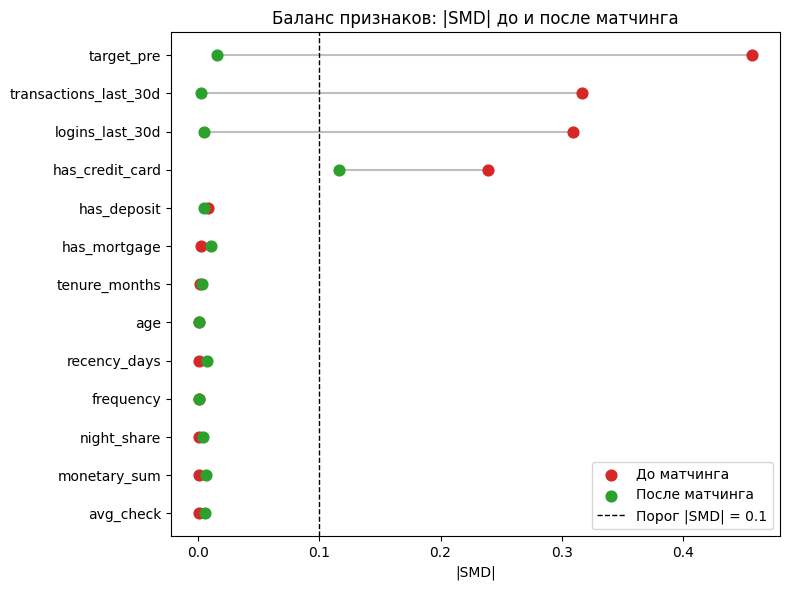

In [43]:
# Love plot: |SMD| по каждому признаку ДО и ПОСЛЕ матчинга.
# Пунктир 0.1 — порог баланса; точки слева от него = признак сбалансирован.
import matplotlib.pyplot as plt

bal = balance.sort_values('SMD_before')          # снизу вверх по возрастанию дисбаланса
y = np.arange(len(bal))

fig, ax = plt.subplots(figsize=(8, 6))
# линии-«сдвиги» между до и после
for yi, b, a in zip(y, bal['SMD_before'], bal['SMD_after']):
    ax.plot([b, a], [yi, yi], color='gray', alpha=0.5, zorder=1)
ax.scatter(bal['SMD_before'], y, color='#d62728', s=60, label='До матчинга', zorder=3)
ax.scatter(bal['SMD_after'],  y, color='#2ca02c', s=60, label='После матчинга', zorder=3)
ax.axvline(0.1, color='black', linestyle='--', linewidth=1, label='Порог |SMD| = 0.1')

ax.set_yticks(y)
ax.set_yticklabels(bal['feature'])
ax.set_xlabel('|SMD|')
ax.set_title('Баланс признаков: |SMD| до и после матчинга')
ax.legend()
plt.tight_layout()
plt.show()


## Распределения признаков: treated vs близнецы

 Дополнительно к SMD — гистограммы и KS-тест по предпериодным признакам для отобранных пар.

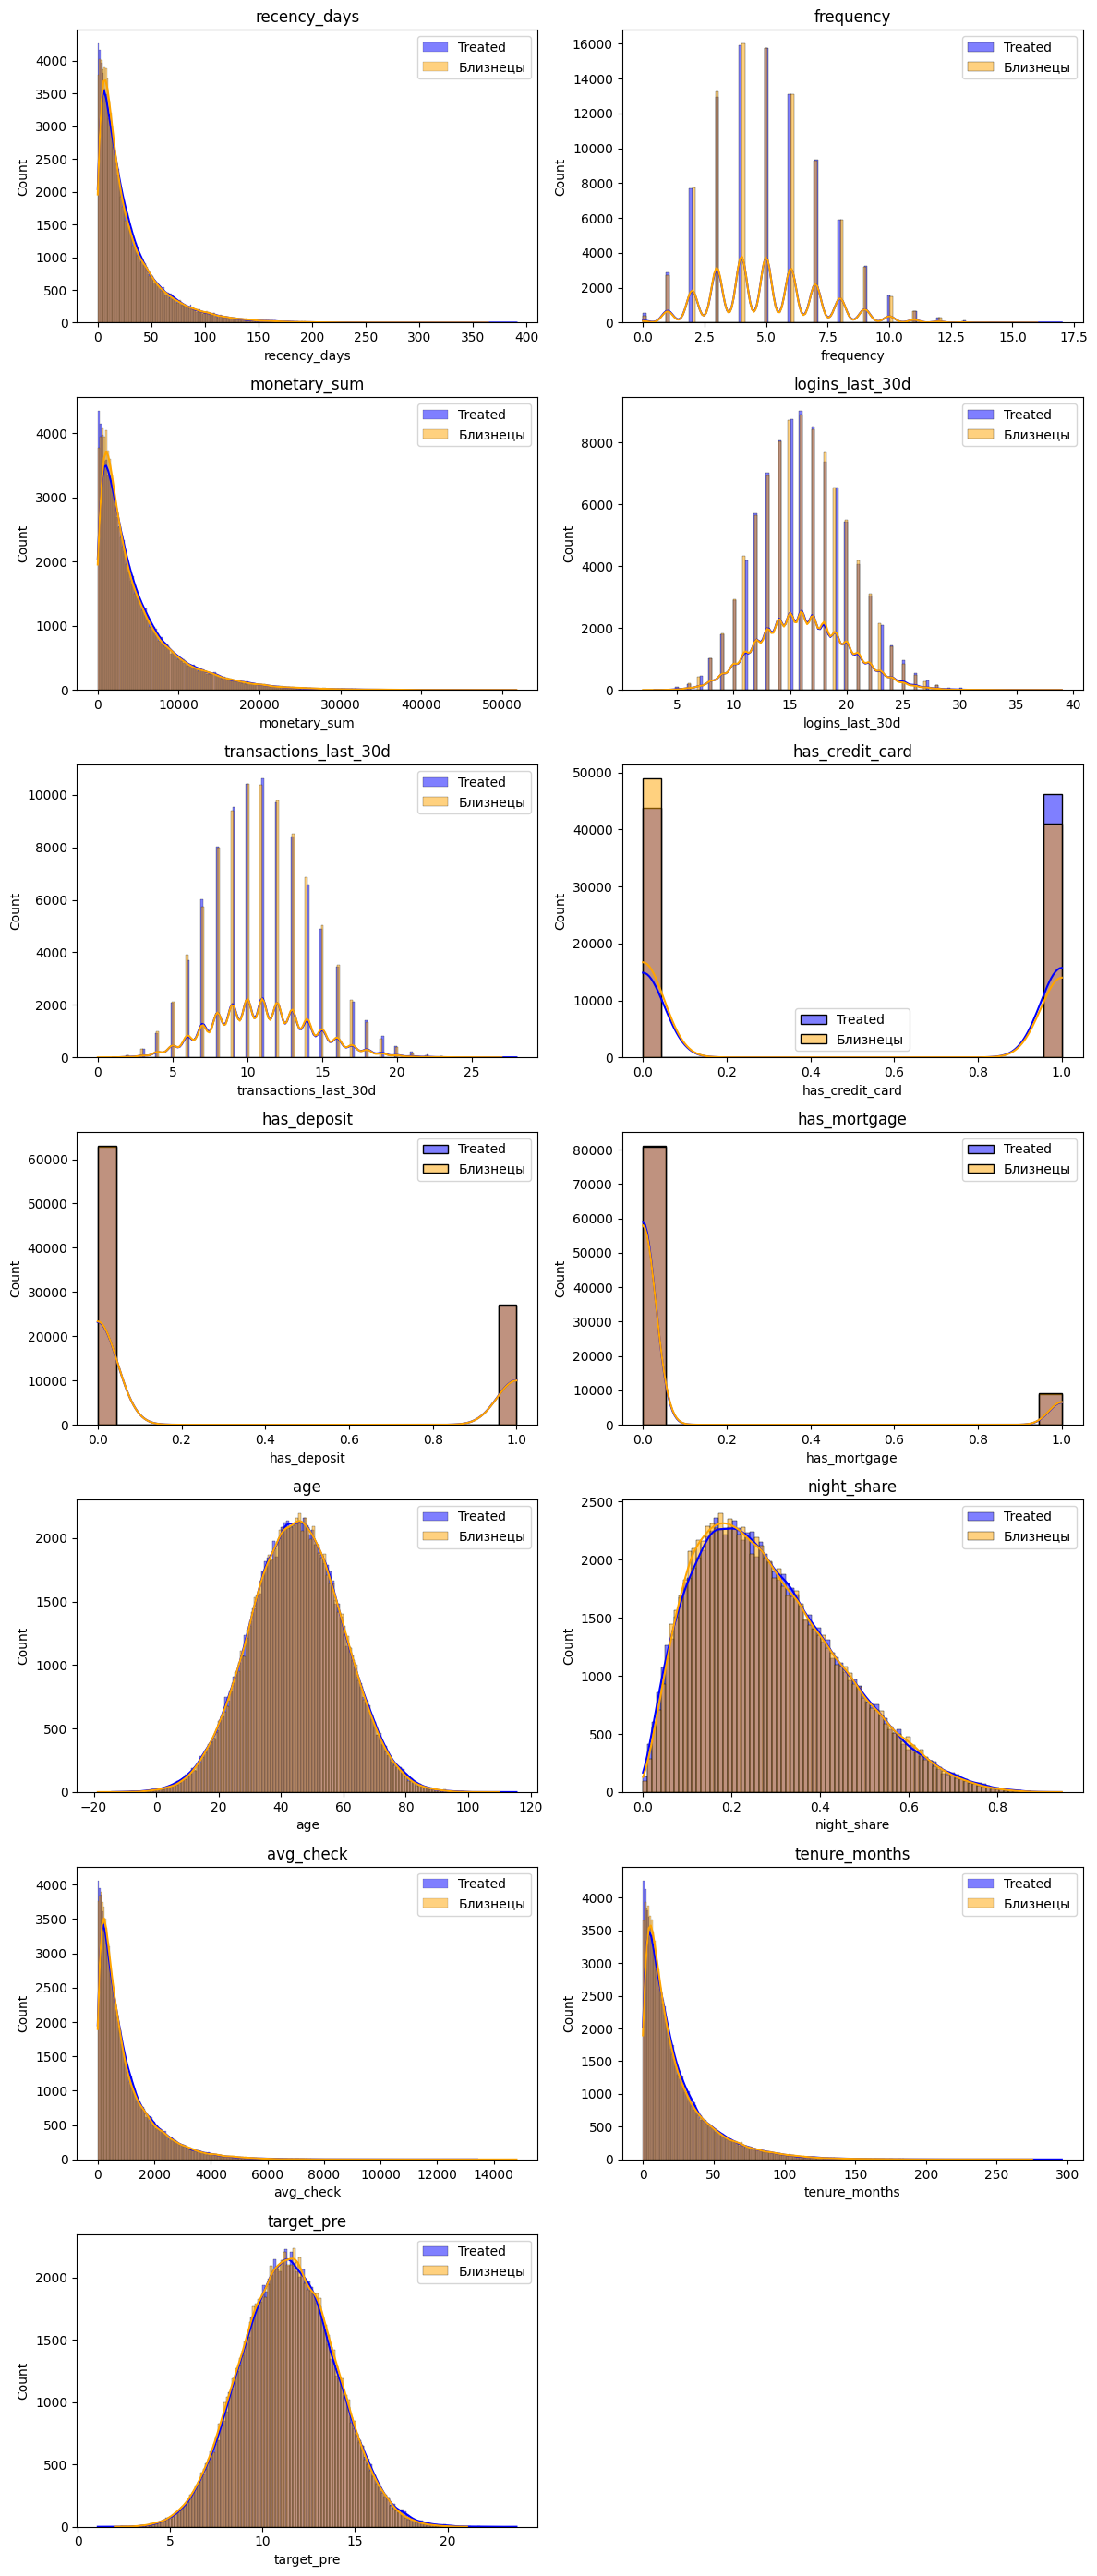

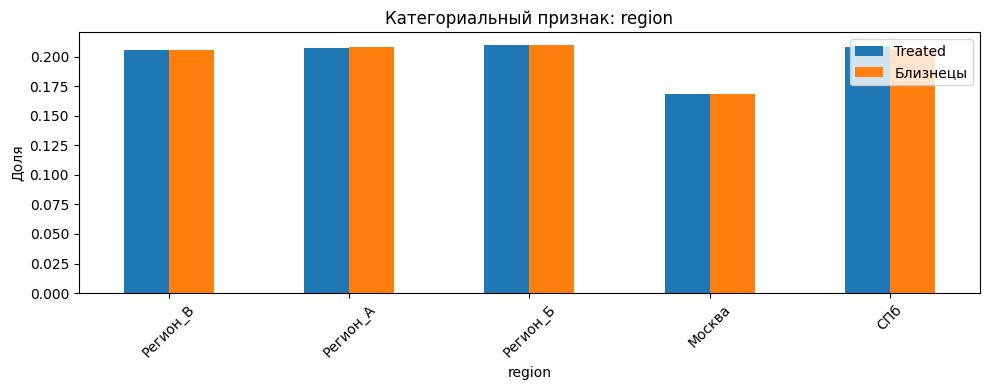

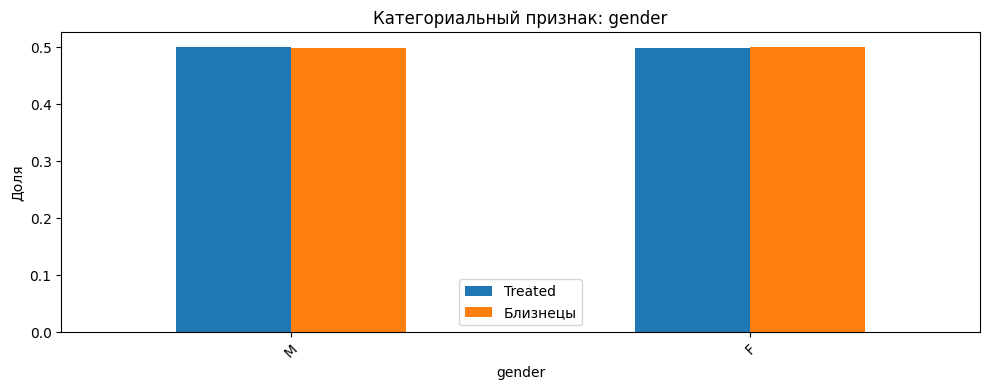

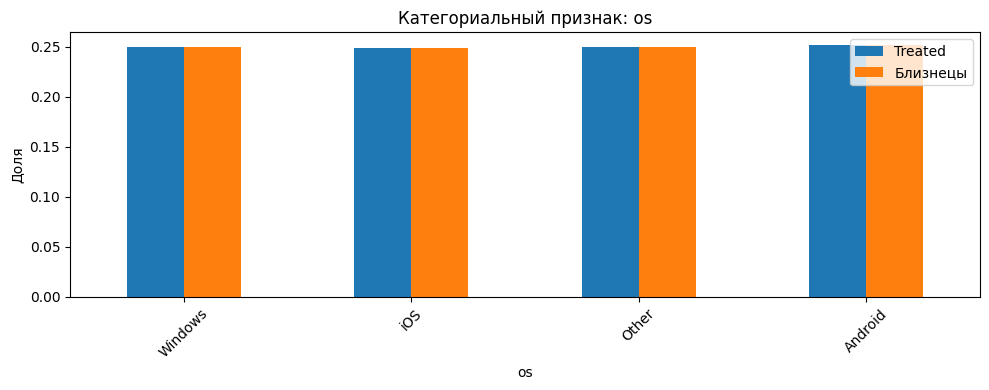

,Treated_mean,Twin_mean,Treated_median,Twin_median,KS_pvalue
recency_days,29.337000,29.091000,19.403999,18.518000,0.000
frequency,4.984000,4.981000,5.000000,5.000000,0.631
monetary_sum,4894.430176,4860.142090,3238.710938,3107.677002,0.000
logins_last_30d,16.186001,16.167000,16.000000,16.000000,0.518
transactions_last_30d,11.024000,11.014000,11.000000,11.000000,0.394
has_credit_card,0.514000,0.456000,1.000000,0.000000,0.000
has_deposit,0.302000,0.300000,0.000000,0.000000,0.938
has_mortgage,0.099000,0.102000,0.000000,0.000000,0.722
age,45.022999,45.009998,45.000999,45.032001,0.583
night_share,0.283000,0.282000,0.260000,0.258000,0.014


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# Сравниваем распределения предпериодных признаков: treated vs их близнецы.
test_ids_v = matched['test_user_id'].values
cand_ids_v = matched['cand_user_id'].values

test_features = df_all[df_all['user_id'].isin(test_ids_v)].copy()
cand_features = df_all[df_all['user_id'].isin(cand_ids_v)].copy()

# Числовые/категориальные колонки; исключаем id, флаг лечения и ПОСТ-метрику (не для баланса).
drop_for_balance = {'user_id', 'treated', 'target_post'}
num_cols = [c for c in test_features.select_dtypes(include=['number']).columns
            if c not in drop_for_balance]
cat_cols = [c for c in test_features.select_dtypes(include=['object', 'category']).columns
            if c not in drop_for_balance]

# 3. Гистограммы числовых признаков (по 2 на ряд)
n = len(num_cols)
if n:
    fig, axes = plt.subplots((n+1)//2, 2, figsize=(12, 4*((n+1)//2)))
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        sns.histplot(test_features[col], color='blue', label='Treated', kde=True, ax=axes[i], alpha=0.5)
        sns.histplot(cand_features[col], color='orange', label='Близнецы', kde=True, ax=axes[i], alpha=0.5)
        axes[i].set_title(col)
        axes[i].legend()
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

# 4. Категориальные — доли по категориям
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    test_counts = test_features[col].value_counts(normalize=True)
    cand_counts = cand_features[col].value_counts(normalize=True)
    all_cats = set(test_counts.index) | set(cand_counts.index)
    df_plot = pd.DataFrame({
        'Treated': test_counts.reindex(all_cats, fill_value=0),
        'Близнецы': cand_counts.reindex(all_cats, fill_value=0)
    })
    df_plot.plot(kind='bar', ax=ax)
    ax.set_title(f'Категориальный признак: {col}')
    ax.set_ylabel('Доля')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5. Сводка средних/медиан + KS для числовых
if num_cols:
    summary = pd.DataFrame({
        'Treated_mean': test_features[num_cols].mean(),
        'Twin_mean': cand_features[num_cols].mean(),
        'Treated_median': test_features[num_cols].median(),
        'Twin_median': cand_features[num_cols].median(),
        'KS_pvalue': [ks_2samp(test_features[col].dropna(), cand_features[col].dropna())[1]
                      for col in num_cols]
    })
    display(summary.round(3))   # .style.background_gradient требует jinja2; без него — обычная таблица


## Оценка эффекта фичи (главный шаг)

 Сравниваем три оценки, чтобы видеть вклад матчинга:
 1. **Наивно** — treated против всего пула по постпериоду (смещено отбором).
 2. **Матчинг, разница уровней** — treated против близнецов на постпериоде.
 3. **Матчинг + DiD** (основная) — попарная разница *изменений* (пост−пред); убирает остаточное постоянное смещение.

 Для (3) — парный t-тест против 0 и 95% доверительный интервал. Корректный метод должен восстановить зашитый `TRUE_EFFECT`, а наивная оценка — заметно от него отклониться.


In [45]:
from scipy import stats

# Пары в одинаковом порядке -> попарные сравнения корректны.
tr = df_all.set_index('user_id').loc[matched['test_user_id'].values]   # treated
ct = df_all.set_index('user_id').loc[matched['cand_user_id'].values]   # их близнецы

d_treat = tr['target_post'].values - tr['target_pre'].values   # изменение пред->пост у treated
d_ctrl  = ct['target_post'].values - ct['target_pre'].values   # изменение у близнецов

# (1) Наивно: treated vs ВЕСЬ кандидатский пул, только постпериод (без матчинга) — смещено отбором
naive = tr['target_post'].mean() - df_all.loc[df_all['treated'] == 0, 'target_post'].mean()

# (2) Матчинг, разница УРОВНЕЙ постпериода
att_levels = (tr['target_post'].values - ct['target_post'].values).mean()

# (3) Матчинг + DiD (попарная разница-в-разностях) — основная, устойчивая оценка
did = d_treat - d_ctrl
att_did = did.mean()
t_stat, p_val = stats.ttest_1samp(did, 0.0)
ci = stats.t.interval(0.95, len(did) - 1, loc=att_did, scale=stats.sem(did))

print(f"Истинный зашитый эффект:        {TRUE_EFFECT:.3f}")
print(f"(1) Наивно (без матчинга):      {naive:+.3f}   <- смещено отбором")
print(f"(2) Матчинг, разница уровней:   {att_levels:+.3f}")
print(f"(3) Матчинг + DiD (основная):   {att_did:+.3f}")
print(f"    95% ДИ: [{ci[0]:.3f}, {ci[1]:.3f}], t={t_stat:.1f}, p={p_val:.2e}")
print("\nВывод:", "эффект ЗНАЧИМ (p<0.05)" if p_val < 0.05 else "эффект НЕзначим (p>=0.05)")


Истинный зашитый эффект:        0.300
(1) Наивно (без матчинга):      +1.694   <- смещено отбором
(2) Матчинг, разница уровней:   +0.337
(3) Матчинг + DiD (основная):   +0.296
    95% ДИ: [0.287, 0.306], t=61.4, p=0.00e+00

Вывод: эффект ЗНАЧИМ (p<0.05)


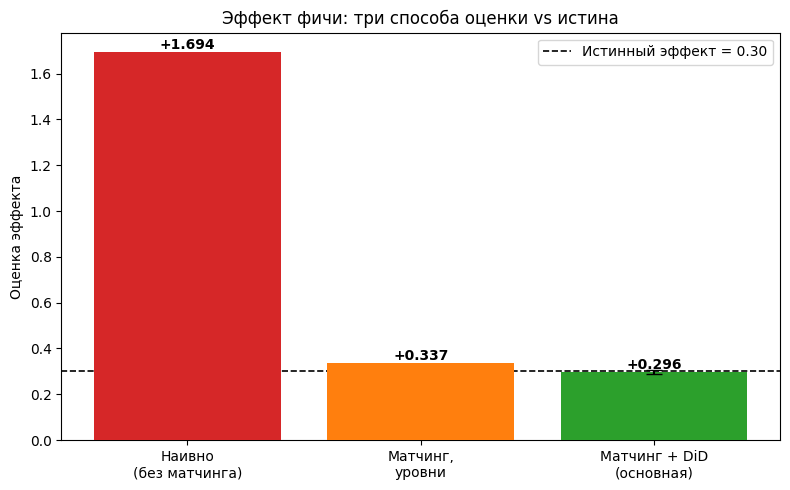

In [46]:
# Сравнение трёх оценок эффекта против зашитой истины.
# Чёрный пунктир — TRUE_EFFECT; чёрный ус на (3) — 95% ДИ.
import matplotlib.pyplot as plt

labels = ['Наивно\n(без матчинга)', 'Матчинг,\nуровни', 'Матчинг + DiD\n(основная)']
values = [naive, att_levels, att_did]
colors = ['#d62728', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, zorder=3)

# 95% ДИ на основную оценку (3)
ax.errorbar(2, att_did, yerr=[[att_did - ci[0]], [ci[1] - att_did]],
            fmt='none', ecolor='black', capsize=6, linewidth=1.5, zorder=4)

# линия истинного эффекта
ax.axhline(TRUE_EFFECT, color='black', linestyle='--', linewidth=1.2,
           label=f'Истинный эффект = {TRUE_EFFECT:.2f}')

# подписи значений над столбцами
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:+.3f}',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Оценка эффекта')
ax.set_title('Эффект фичи: три способа оценки vs истина')
ax.legend()
plt.tight_layout()
plt.show()


 ## 9. Сохранение индекса FAISS (для переиспользования)

 Индекс можно сохранить на диск, чтобы не перестраивать каждый раз.


In [47]:
# faiss.write_index(index, "faiss_index_ivfpq.index")
# print("Индекс сохранён.")


## Выводы

 **Что делает пайплайн:** подбирает уникальных «близнецов» из непролеченной популяции по предпериодным признакам (FAISS IVFPQ + переранжирование точным косинусом), проверяет баланс и **оценивает эффект фичи** с тестом значимости.

 **Методология:**
 - Эффект меряется тремя способами; основная оценка — **матчинг + DiD** (попарная разница изменений), которая устойчивее разницы уровней и должна восстановить зашитый `TRUE_EFFECT`. Наивное сравнение смещено отбором — это видно по строке (1).
 - **Валидность держится на допущении CIA** (отбор в фичу — только по наблюдаемым признакам). Здесь это смоделировано явно; на реальных данных нужно обосновать, как отбирались 100k, и проверить чувствительность к скрытым конфаундерам (напр. Rosenbaum bounds).
 - Баланс контролируется через **SMD до/после** (цель < 0.1) и **caliper** (плохие пары отбрасываются).

 **Инженерия / память:**
 - Узкое место — не FAISS, а препроцессинг. Поэтому всё во **float32**, промежуточные массивы удаляются. На проде 20 млн признаки/индекс строить **батчами**.
 - Обучение IVFPQ — на случайной подвыборке ~40·nlist (не на первых 10k).

 **Что ещё можно усилить:** 1:k-матчинг или взвешивание для меньшей дисперсии; абсолютный caliper по стандартизованному расстоянию; bootstrap-ДИ с учётом неопределённости подбора; A/A-прогон (`TRUE_EFFECT=0`) для проверки отсутствия ложноположительных.
